# Final presentation (22.06.2026)

This is the code used for visualizations and tables from the presentation that were not covered in the notebooks before.

Please note that this code was set up before the presentation on 22.06.2026 and that I have changed the code in the notebooks since then.
I changed the settings for tuning hyperparameters and corrected the interpretation of the R-Score, which is why I chose to use the X-Learner instead of the T-Learner as stated in the presentation, and the plots might look a little different.

Overall, the results from the presentation stayed the same.

In [1]:
# Load packages and data

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import math
import patsy
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

!pip install econml
from econml.metalearners import TLearner
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

!pip install causaldata
import causaldata



In [2]:
# Load the dataset
df_raw = causaldata.nsw_mixtape.load_pandas().data

# Remove specified columns from df
df=df_raw.copy()
df = df.drop(columns=['marr', 'hisp', 'nodegree', 're74'], errors='ignore')

# Handle zeros in re78 before taking log (do +1)
ly78 = np.log(df['re78'] + 1)
ly75 = np.log(df['re75'] + 1)

df['lre78'] = ly78
df['lre75'] = ly75

# Model with all features
X = df[['treat', 'age', 'educ', 'black', 'lre75']]

# Data

In this section, I am setting up the summary statistics table as well as the DAG constructed under the PC-Algorithm.



## Summary Statistics

In [3]:
print(df_raw.describe())

            treat         age        educ       black       hisp        marr  \
count  445.000000  445.000000  445.000000  445.000000  445.00000  445.000000   
mean     0.415730   25.370787   10.195506    0.833708    0.08764    0.168539   
std      0.493402    7.100282    1.792119    0.372762    0.28309    0.374766   
min      0.000000   17.000000    3.000000    0.000000    0.00000    0.000000   
25%      0.000000   20.000000    9.000000    1.000000    0.00000    0.000000   
50%      0.000000   24.000000   10.000000    1.000000    0.00000    0.000000   
75%      1.000000   28.000000   11.000000    1.000000    0.00000    0.000000   
max      1.000000   55.000000   16.000000    1.000000    1.00000    1.000000   

         nodegree          re74          re75          re78  
count  445.000000    445.000000    445.000000    445.000000  
mean     0.782022   2102.265381   1377.138306   5300.764160  
std      0.413337   5363.584961   3150.956787   6631.500000  
min      0.000000      0.000000

In [4]:
summary_stats = df_raw.describe()
summary_stats.to_csv('summary_statistics_raw_data.csv')

## DAG

In [5]:
# Causal structural model / DAG

# Preparations

!pip install DoWhy
!pip install gcastle
!pip install cdt
import cdt
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import dowhy.gcm as gcm
from castle.algorithms import PC
from castle.algorithms.pc.pc import find_skeleton
from castle.common import GraphDAG
from castle.metrics import MetricsDAG

# Set colours for plots (copyright for setup code: Ryan OSullivan: https://github.com/raz1470/causal_ai/blob/main/notebooks/making%20causal%20discovery%20work%20in%20real%20world%20business%20settings.ipynb)
COLORS = [
    '#00B0F0',
    '#FF0000',
    '#B0F000'
]

def plot_graph(input_graph, node_lookup, filename=None):
    '''
    Function to visualise graphs.

    Args:
        input_graph (array): Adjacency matrix representing graph
        node_lookup (dict): Dictionary containing node names.
        filename (str, optional): If provided, saves the graph to this filename.
    '''

    graph = nx.DiGraph(input_graph)

    plt.figure(figsize=(8,8))
    nx.draw(
    G=graph,
    node_color=COLORS[0],
    node_size=8000,
    arrowsize=17,
    with_labels=True,
    labels=node_lookup,
    font_color='white',
    font_size=9,
    pos=nx.circular_layout(graph)
    )
    if filename:
        plt.savefig(filename)
        print(f"Graph saved to {filename}")
    plt.show()

    # add logged values
df_raw['lre78'] = ly78
df_raw['lre75'] = ly75
df_raw['lre74'] = np.log(df_raw['re74'] + 1)


data_for_dag = df_raw[['age', 'educ', 'black', 'hisp', 'marr', 'nodegree', 'treat', 'lre78', 'lre75', 'lre74']].copy()
names_var_dag={0: 'age',
               1: 'educ',
               2: 'black',
               3: 'hisp',
               4: 'marr',
               5: 'nodegree',
                6: 'treat',
                7: 'lre78',
                8: 'lre75',
                9: 'lre74'
 }

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 921.1/921.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.0 MB/s eta 0:00:00
  Created wheel for GPUtil: filename=GPUtil-1.4.0-py3-none-any.whl size=7392 sha256=b2cad277d34e5e6a9a0e9169fae028164780b7fe09237f56dd89b5fc1d8584b0
  Stored in directory: /root/.cache/pip/wheels/92/a8/b7/d8a067c31a74de9ca252bbe53dea5f896faabd25d55f541037
Successfully built GPUtil


No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


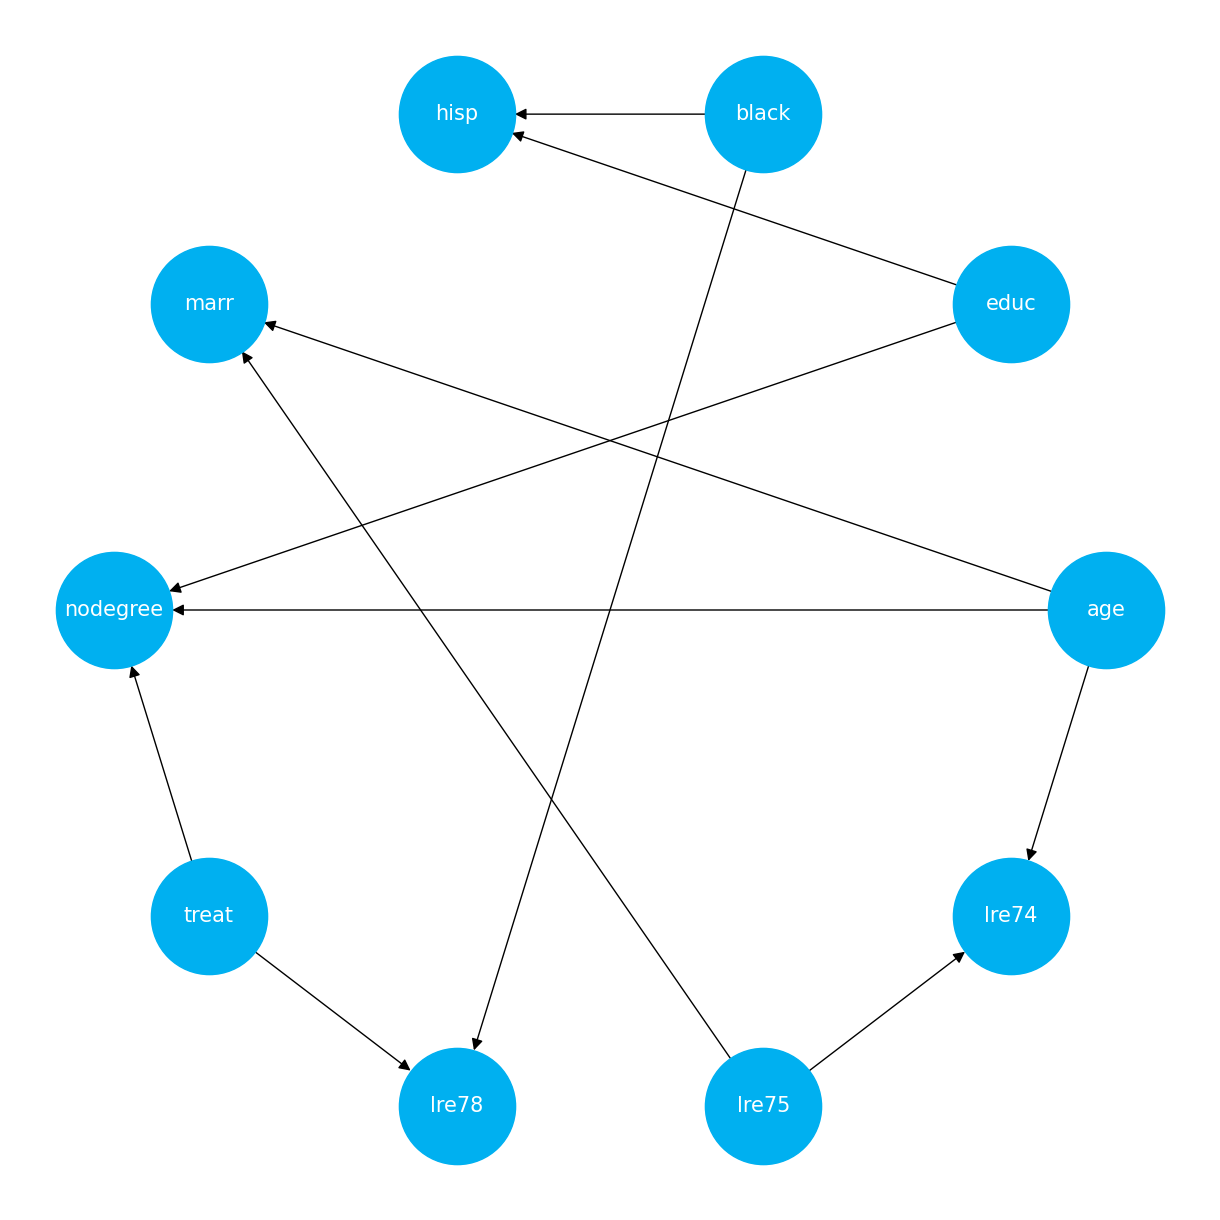

In [6]:
# Step 1: Naive DAG

# skeleton
skeleton_pred, sep_set = find_skeleton(data_for_dag.to_numpy(), 0.1, 'fisherz') # also try chi2 g2 instead of fisherz

# DAG
pc = PC(variant='stable', ci_test='fisherz', alpha=0.1) # make sure this is aligned with the skeleton graph settings
pc.learn(data_for_dag)
graph_pred = pc.causal_matrix

graph = nx.DiGraph(graph_pred)
plt.figure(figsize=(12,12))
pos = nx.circular_layout(graph, scale=1.3)
nx.draw(
    G=graph,
    node_color=COLORS[0],
    node_size=7000,
    arrowsize=17,
    with_labels=True,
    labels=names_var_dag,
    font_color='white',
    font_size=15,
    pos=pos
)
plt.axis('off')
plt.savefig('naive_dag.png', bbox_inches='tight')
plt.show()

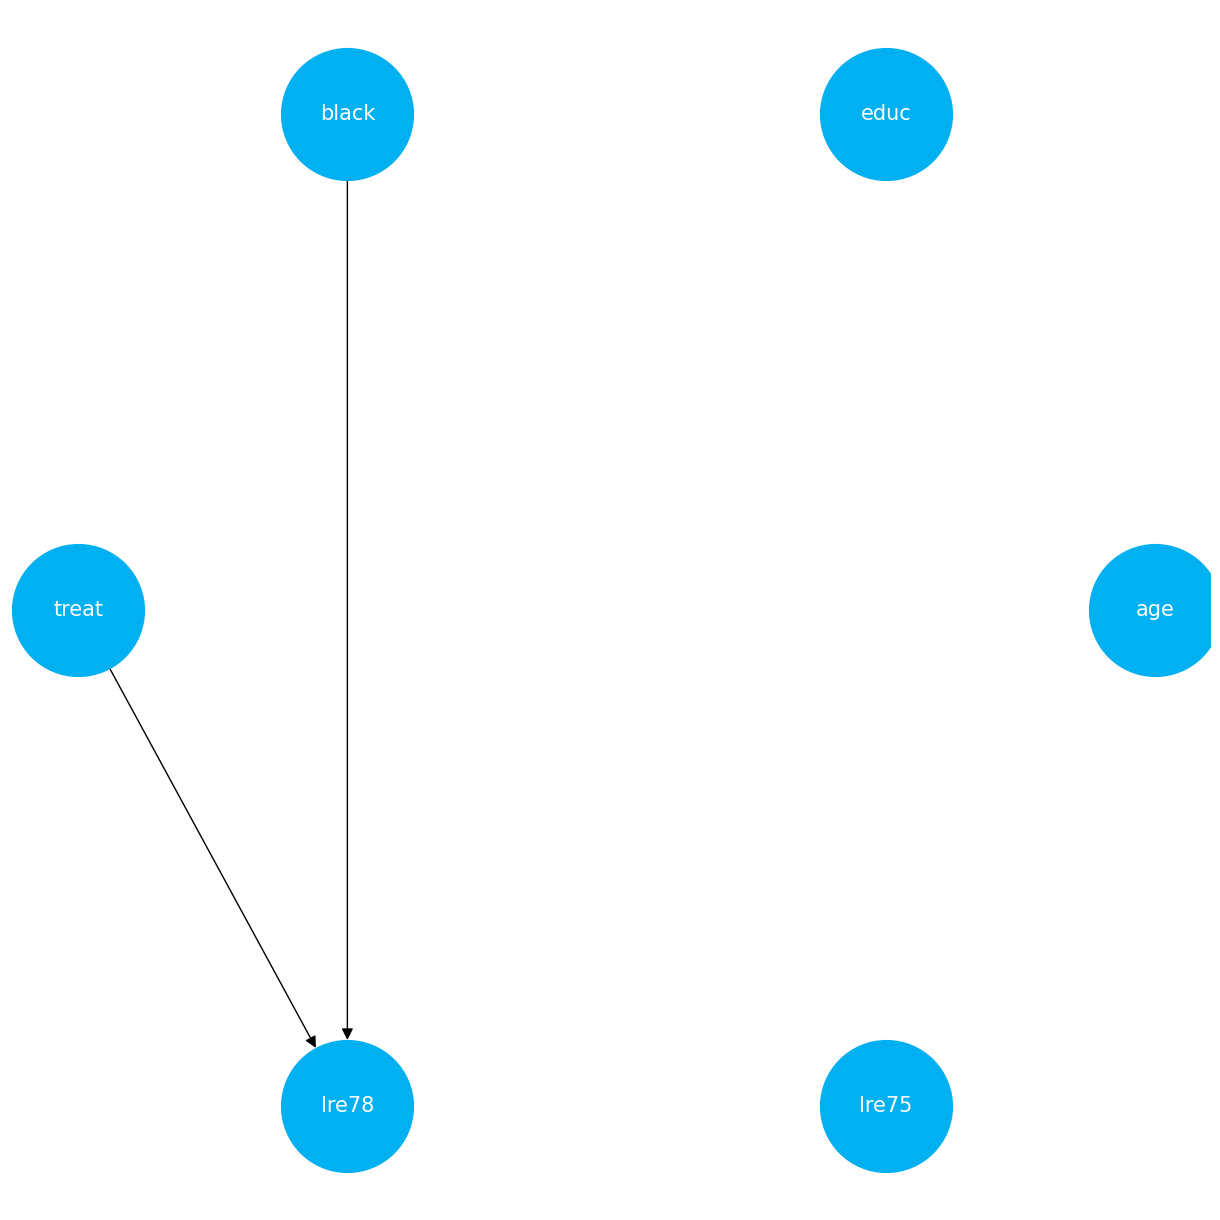

In [7]:
# Improved DAG without colliders

# Nodes to be removed:
nodes_to_remove = ['hisp', 'nodegree', 'marr', 'lre74']

for node_to_remove in nodes_to_remove:
    index_to_remove = -1
    for index, name in list(names_var_dag.items()):
        if name == node_to_remove:
            index_to_remove = index
            break

    if index_to_remove == -1:
        print(f"Node '{node_to_remove}' not found")
    else:
        updated_names_var_dag = {}
        current_new_index = 0

        original_indices_before_removal = sorted(names_var_dag.keys())

        new_index_mapping = {}
        for original_idx in original_indices_before_removal:
            if original_idx != index_to_remove:
                new_index_mapping[original_idx] = current_new_index
                updated_names_var_dag[current_new_index] = names_var_dag[original_idx]
                current_new_index += 1

        updated_graph_pred = np.delete(graph_pred, index_to_remove, axis=0)
        updated_graph_pred = np.delete(updated_graph_pred, index_to_remove, axis=1)

        graph_pred = updated_graph_pred
        names_var_dag = updated_names_var_dag

graph = nx.DiGraph(graph_pred)
plt.figure(figsize=(12,12))
pos = nx.circular_layout(graph, scale=0.5)
nx.draw(
    G=graph,
    node_color=COLORS[0],
    node_size=9000,
    arrowsize=17,
    with_labels=True,
    labels=names_var_dag,
    font_color='white',
    font_size=15,
    pos=pos
)
plt.axis('off')
plt.savefig('DAG_no_colliders.png', bbox_inches='tight')
plt.show()

According to the DAG, I will use these final structural models:

Linear model:

$$
\log(re_{78})=\beta_0+\beta_1 treat+\beta_2 black+\beta_3 educ+ \beta_4 age+\beta_5 \log(re_{75}) + \epsilon
$$

Flexible model:

$$
\log(re_{78})=\beta_0+\beta_1 treat+\beta_2 black+ \beta_3 black \ x\  educ +\beta_4 educ + \beta_5 age + \beta_6 age^2 +\beta_7 \log(re_{75}) + υ
$$

# Regression & Forest models

In this section, I will plot the ATE & CATEs of both best models (linear OLS and Regression Forest / X-Learner) next to each other.



## Linear OLS


In [8]:
# Data preparation for AIPW

# set up model without 'treat'
model_base_aipw = 'lre78 ~ age + educ + C(black) + lre75'
tmp_aipw = smf.ols(model_base_aipw, data=df)
X_aipw = tmp_aipw.data.exog
y_aipw = tmp_aipw.data.endog
T_aipw = df['treat'].values

# Define the number of splits for cross-fitting
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=1)

# Initialize arrays to store out-of-fold predictions
m0_oof = np.zeros(len(df))
m1_oof = np.zeros(len(df))
p_scores_oof = np.zeros(len(df))
y_oof = np.zeros(len(df))
T_oof = np.zeros(len(df))

# Cross-fitting
for fold, (train_index, test_index) in enumerate(kf.split(X_aipw)):
    # Split data for the current fold
    X_train_fold, X_test_fold = X_aipw[train_index], X_aipw[test_index]
    y_train_fold, y_test_fold = y_aipw[train_index], y_aipw[test_index]
    T_train_fold, T_test_fold = T_aipw[train_index], T_aipw[test_index]

    # Store actual y and T values for the test fold
    y_oof[test_index] = y_test_fold
    T_oof[test_index] = T_test_fold

# Estimate propensity score (logistic regression)
    X_train_non_intercept = X_train_fold[:, 1:]
    X_test_non_intercept = X_test_fold[:, 1:]

    scaler = StandardScaler()
    X_train_scaled = np.hstack((X_train_fold[:, :1], scaler.fit_transform(X_train_non_intercept)))
    X_test_scaled = np.hstack((X_test_fold[:, :1], scaler.transform(X_test_non_intercept)))

    propensity_model = LogisticRegression(solver='liblinear', random_state=1, fit_intercept=False)
    propensity_model.fit(X_train_scaled, T_train_fold)

    # Predict propensity scores for the test fold
    p_scores_oof[test_index] = propensity_model.predict_proba(X_test_scaled)[:, 1]

# Estimate outcome model for control group (T=0)
    X_train_control = X_train_fold[T_train_fold == 0]
    y_train_control = y_train_fold[T_train_fold == 0]

    ols_m0 = sm.OLS(y_train_control, X_train_control).fit()

    m0_oof[test_index] = ols_m0.predict(X_test_fold)

# Estimate outcome model for treatment group (T=1)
    X_train_treated = X_train_fold[T_train_fold == 1]
    y_train_treated = y_train_fold[T_train_fold == 1]

    ols_m1 = sm.OLS(y_train_treated, X_train_treated).fit()

    m1_oof[test_index] = ols_m1.predict(X_test_fold)

# Ensure overlap of propensity scores (clip)
epsilon = 1e-7
p_scores_oof = np.clip(p_scores_oof, epsilon, 1 - epsilon)

# Calculate ATE with out-of-fold predictions
aipw_terms = (m1_oof - m0_oof +
              (T_oof * (y_oof - m1_oof) / p_scores_oof) +
              ((1 - T_oof) * (y_oof - m0_oof) / (1 - p_scores_oof)))

ate_aipw_crossfit = np.mean(aipw_terms)

# Calculate percentage from log values
ate_aipw_pc = (math.exp(ate_aipw_crossfit)-1)*100

print(f"ATE from linear OLS: {ate_aipw_pc}")


# CATE
X_covariates = df[['age', 'educ', 'black', 'lre75']].values

ols_cate = sm.OLS(aipw_terms, sm.add_constant(X_covariates)).fit() # regress on X to get conditional values

# CATEs = fitted values
cates = ols_cate.fittedvalues
cate_pc = (np.exp(cates) - 1) * 100

ATE from linear OLS: 179.92811548878979


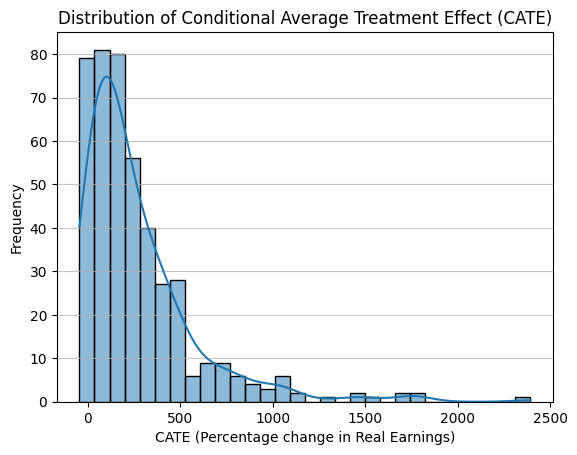

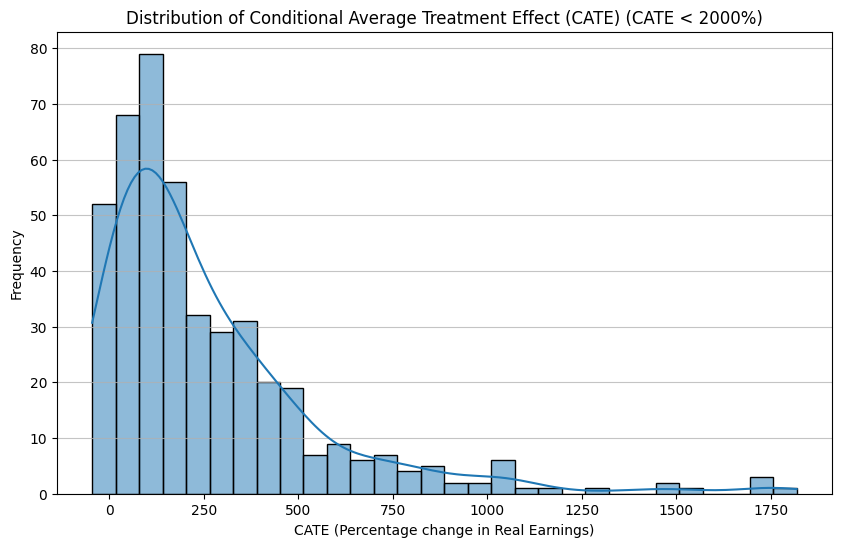

In [9]:
# plot of CATE

sns.histplot(cate_pc, bins=30, kde=True)
plt.title('Distribution of Conditional Average Treatment Effect (CATE)')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Filter CATE values smaller than 2000%
cate_pc_filtered = cate_pc[cate_pc < 2000]

plt.figure(figsize=(10, 6))
sns.histplot(cate_pc_filtered, bins=30, kde=True)
plt.title('Distribution of Conditional Average Treatment Effect (CATE) (CATE < 2000%)')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()



## T-Learner

In [10]:
# Forest model, T-Learner

# Set variables
Y = df['lre78'].values
T = df['treat']
X_covariates = df[['age', 'educ', 'black', 'lre75']].values
y_ate_full = df['lre78'].values
design_info_full_ate = patsy.dmatrix('age + educ + black +lre75 + treat', data=df, return_type='dataframe').design_info
X_ate_full = patsy.dmatrix('age + educ + black + lre75 + treat', data=df, return_type='dataframe').values


# Initialize KFold
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Array to store out-of-fold CATE predictions
cate_t_learner_opt_oof = np.zeros(len(df))

for fold, (train_index, test_index) in enumerate(kf.split(X_covariates)):

    # Split data for the current fold
    Y_train, Y_test = Y[train_index], Y[test_index]
    T_train, T_test = T[train_index], T[test_index]
    X_covariates_train, X_covariates_test = X_covariates[train_index], X_covariates[test_index]

    # Define the base learners
    tl_model_y0_fold = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=1,
        min_samples_split=2,
        n_jobs=1
    )
    tl_model_y1_fold = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=1,
        min_samples_split=2,
        n_jobs=1
    )

    # Initialize a new T-Learner
    tl_opt_fold = TLearner(
        models=[tl_model_y0_fold, tl_model_y1_fold]
    )

    # Fit the T-Learner on the training data
    tl_opt_fold.fit(Y_train, T_train, X=X_covariates_train)

    # Predict CATE on the test data
    cate_t_learner_opt_oof[test_index] = tl_opt_fold.effect(X=X_covariates_test)

# CATE estimates
cate_t_learner_opt = cate_t_learner_opt_oof
cate_t_learner_pc_opt = (np.exp(cate_t_learner_opt) - 1) * 100

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


In [24]:
# Forest model ATE via AIPW

T = df['treat']
X_covariates = df[['age', 'educ', 'black', 'lre75']].values
y_ate_full = df['lre78'].values
design_info_full_ate = patsy.dmatrix('age + educ + black +lre75 + treat', data=df, return_type='dataframe').design_info
X_ate_full = patsy.dmatrix('age + educ + black + lre75 + treat', data=df, return_type='dataframe').values

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize arrays to store out-of-fold predictions
p_scores_oof_rf_optimal = np.zeros(len(df))
m0_oof_rf_optimal = np.zeros(len(df))
m1_oof_rf_optimal = np.zeros(len(df))
y_oof_rf_optimal = np.zeros(len(df))
T_oof_rf_optimal = np.zeros(len(df))


for fold, (train_index, test_index) in enumerate(kf.split(X_covariates)):

    # Split data for current fold
    X_covariates_train, X_covariates_test = X_covariates[train_index], X_covariates[test_index]
    T_train, T_test = T.iloc[train_index], T.iloc[test_index]
    y_ate_full_train, y_ate_full_test = y_ate_full[train_index], y_ate_full[test_index]
    X_ate_full_train, X_ate_full_test = X_ate_full[train_index], X_ate_full[test_index]

    # Propensity score model
    propensity_model_rf_optimal = LogisticRegression(solver='liblinear', random_state=42)
    propensity_model_rf_optimal.fit(X_covariates_train, T_train)
    p_scores_fold_rf_optimal = propensity_model_rf_optimal.predict_proba(X_covariates_test)[:, 1]
    p_scores_oof_rf_optimal[test_index] = p_scores_fold_rf_optimal

    # Outcome model
    rf_outcome_ate_optimal = Pipeline([
        ('scale', StandardScaler()),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42,
                                     max_depth=1,
                                     min_samples_split=2,
                                     n_jobs=1))
    ])
    rf_outcome_ate_optimal.fit(X_ate_full_train[:, 1:], y_ate_full_train)

    # Counterfactual dataframes for the test fold
    df_treated_cf_fold_rf_optimal = df.iloc[test_index].copy()
    df_treated_cf_fold_rf_optimal['treat'] = 1

    df_control_cf_fold_rf_optimal = df.iloc[test_index].copy()
    df_control_cf_fold_rf_optimal['treat'] = 0

    X_treated_cf_fold_rf_optimal = patsy.build_design_matrices([design_info_full_ate], data=df_treated_cf_fold_rf_optimal)[0]
    X_control_cf_fold_rf_optimal = patsy.build_design_matrices([design_info_full_ate], data=df_control_cf_fold_rf_optimal)[0]

    # Predict potential outcomes for the test fold
    m1_fold_rf_optimal = rf_outcome_ate_optimal.predict(X_treated_cf_fold_rf_optimal[:, 1:])
    m0_fold_rf_optimal = rf_outcome_ate_optimal.predict(X_control_cf_fold_rf_optimal[:, 1:])

    m1_oof_rf_optimal[test_index] = m1_fold_rf_optimal
    m0_oof_rf_optimal[test_index] = m0_fold_rf_optimal
    y_oof_rf_optimal[test_index] = y_ate_full_test
    T_oof_rf_optimal[test_index] = T_test

# Trim propensity scores
p_scores_oof_rf_optimal = np.clip(p_scores_oof_rf_optimal, 0.01, 0.99)

# Calculate ATE via AIPW
aipw_terms_rf_optimal = (m1_oof_rf_optimal - m0_oof_rf_optimal +
                         (T_oof_rf_optimal * (y_oof_rf_optimal - m1_oof_rf_optimal) / p_scores_oof_rf_optimal) +
                         ((1 - T_oof_rf_optimal) * (y_oof_rf_optimal - m0_oof_rf_optimal) / (1 - p_scores_oof_rf_optimal)))

# ATE
ate_aipw_crossfit_rf_optimal = np.mean(aipw_terms_rf_optimal)

ATE_rf_optimal_pc = (math.exp(ate_aipw_crossfit_rf_optimal)-1)*100
print(ATE_rf_optimal_pc)

33.616053749735045


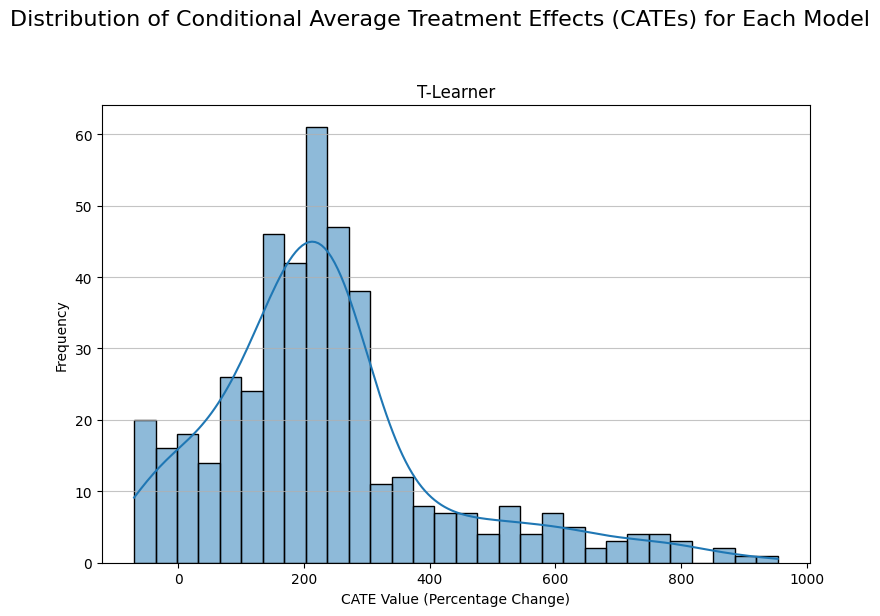

In [12]:
# Plot of CATE
cate_models = {
    'T-Learner': cate_t_learner_pc_opt
}

fig, axes = plt.subplots(len(cate_models), 1, figsize=(8, 6), squeeze=False)
axes = axes.flatten()

# Iterate through models
for i, (model_name, cate_values) in enumerate(cate_models.items()):
    sns.histplot(cate_values, bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'{model_name}', fontsize=12)
    axes[i].set_xlabel('CATE Value (Percentage Change)', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', alpha=0.75)

plt.suptitle('Distribution of Conditional Average Treatment Effects (CATEs) for Each Model', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Plot comparisons

## ATE

233.2878861586887


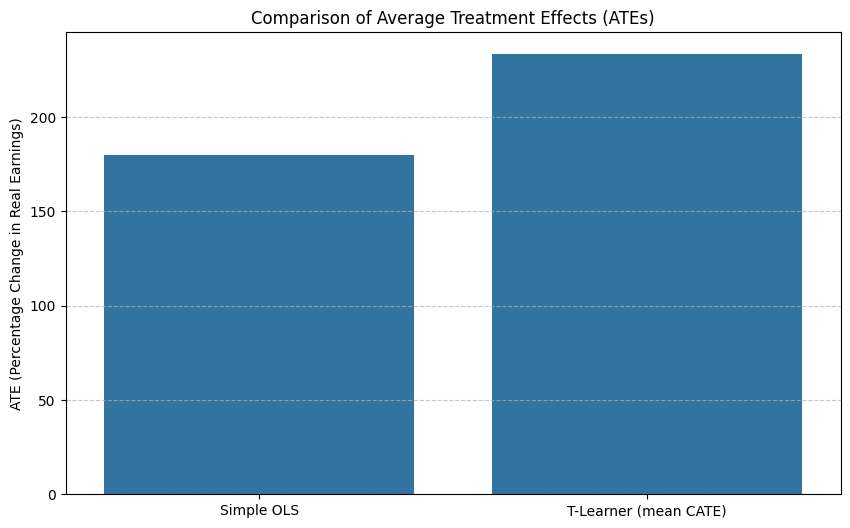

In [13]:
# Calculate ATE for T-Learner (mean of CATEs)
ate_t_learner_pc = np.mean(cate_t_learner_pc_opt)
print (ate_t_learner_pc)

ate_data = pd.DataFrame({
    'Model': ['Simple OLS','T-Learner (mean CATE)'],
    'ATE (Percentage Change)': [ate_aipw_pc, ate_t_learner_pc]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='ATE (Percentage Change)', data=ate_data)
plt.title('Comparison of Average Treatment Effects (ATEs)')
plt.ylabel('ATE (Percentage Change in Real Earnings)')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('ate_combined.png', bbox_inches='tight')
plt.show()

Now, I am adding calculations to give an intuition which earnings increases (in money terms of 1975) these ATEs would correspond to. This is for the average incomes of both the bottom quintile and the second quintile of the U.S. earnings distribution of 1975.

In [14]:
inc_botquint= 2910 # bottom quintile, from https://taxpolicycenter.org/sites/default/files/statistics/pdf/income_quintiles_5.pdf
inc_secquint = 7150 # second quintile

# OLS
OLS_inc_botquint = inc_botquint*(1+ate_aipw_pc/100)
print(f"OLS bottom quintile: {OLS_inc_botquint}")

# RF AIPW
RF_inc_botquint = inc_botquint*(1+ATE_rf_optimal_pc/100)
print(f"RF AIPW bottom quintile: {RF_inc_botquint}")

# T-Learner
T_inc_botquint = inc_botquint*(1+ate_t_learner_pc/100)
print(f"T-Learner bottom quintile: {T_inc_botquint}")

# second quintile
# OLS
OLS_inc_secquint = inc_secquint*(1+ate_aipw_pc/100)
print(f"OLS second quintile: {OLS_inc_secquint}")

# RF AIPW
RF_inc_secquint = inc_secquint*(1+ATE_rf_optimal_pc/100)
print(f"RF AIPW second quintile: {RF_inc_secquint}")

# T-Learner
T_inc_secquint = inc_secquint*(1+ate_t_learner_pc/100)
print(f"T-Learner second quintile: {T_inc_secquint}")

OLS bottom quintile: 8145.908160723782
RF AIPW bottom quintile: 3888.2271641172897
T-Learner bottom quintile: 9698.677487217841
OLS second quintile: 20014.86025744847
RF AIPW second quintile: 9553.547843106055
T-Learner second quintile: 23830.083860346243


In [15]:
table_forest = pd.DataFrame({
    'Base 1975': [inc_botquint, inc_secquint, 0],
    'OLS': [OLS_inc_botquint, OLS_inc_secquint, OLS_inc_botquint-inc_botquint], # Keeping ATE-based metrics for the tuned RF here
    'RF AIPW': [RF_inc_botquint, RF_inc_secquint, RF_inc_botquint-inc_botquint],
    'T-Learner': [T_inc_botquint, T_inc_secquint, T_inc_botquint-inc_botquint]
}).T
table_forest.columns = ['Bottom quintile', 'Second quintile', 'Difference botquint']
display(table_forest)

,Bottom quintile,Second quintile,Difference botquint
Base 1975,2910.000000,7150.000000,0.000000
OLS,8145.908161,20014.860257,5235.908161
RF AIPW,3888.227164,9553.547843,978.227164
T-Learner,9698.677487,23830.083860,6788.677487


## CATE

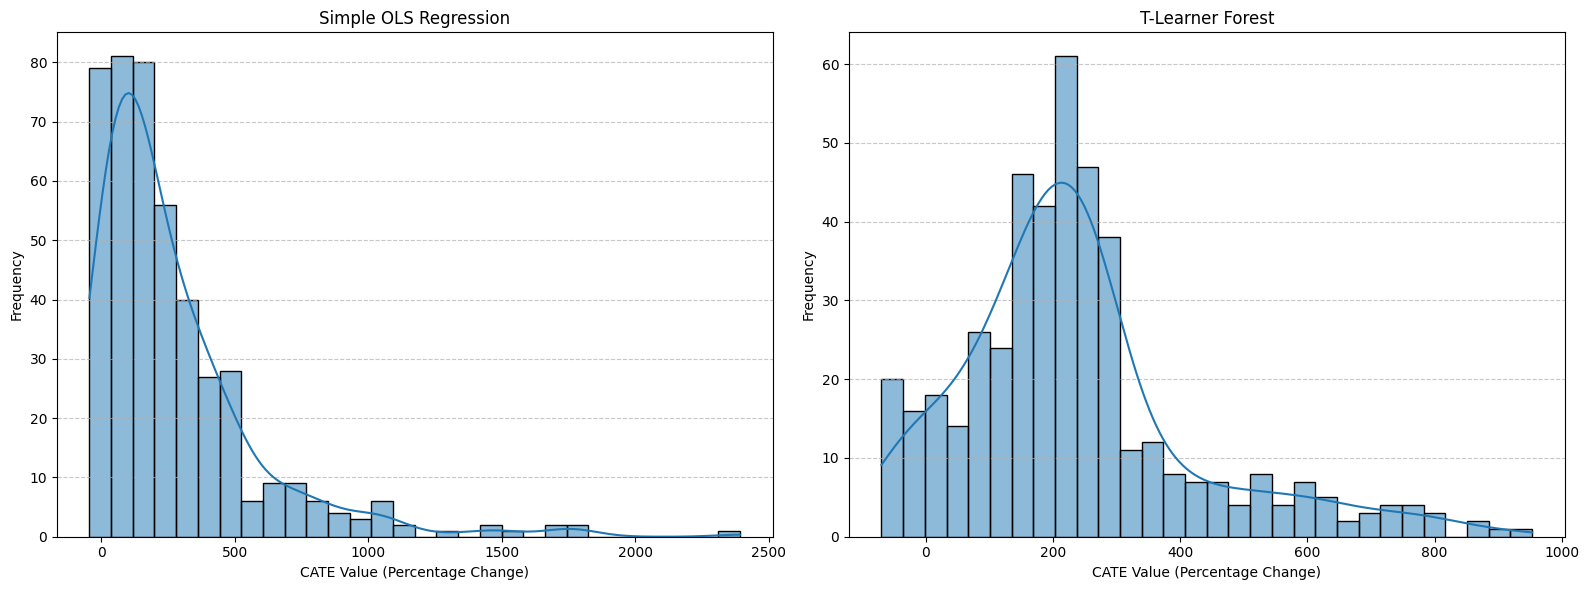

In [16]:
cate_models_combined = {
    'Simple OLS Regression': cate_pc,
    'T-Learner Forest': cate_t_learner_pc_opt
}

fig, axes = plt.subplots(1, len(cate_models_combined), figsize=(16, 6), squeeze=False)
axes = axes.flatten()

for i, (model_name, cate_values) in enumerate(cate_models_combined.items()):
    sns.histplot(cate_values, bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'{model_name}', fontsize=12)
    axes[i].set_xlabel('CATE Value (Percentage Change)', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

#plt.suptitle('Distribution of Conditional Average Treatment Effects (CATEs)', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('cate_distributions_combined.png')
plt.show()

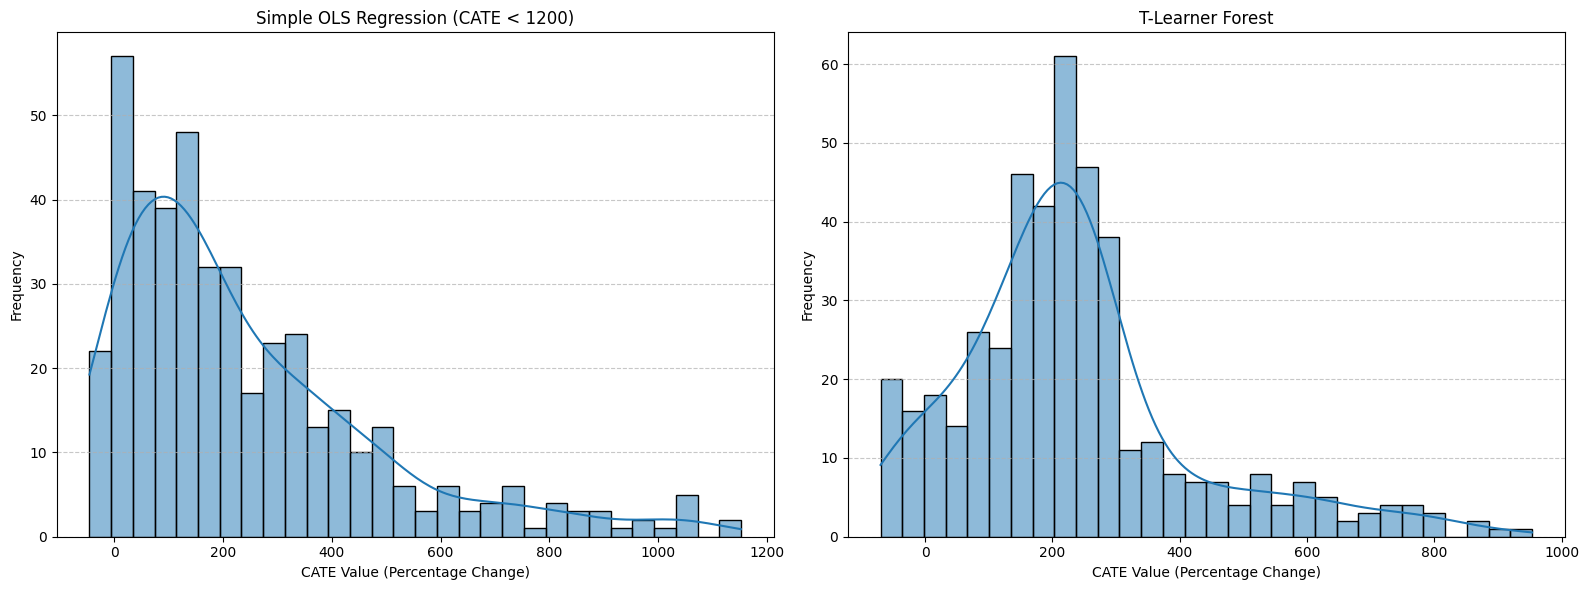

In [17]:
# Filter cate_pc
cate_pc_filtered = cate_pc[cate_pc < 1200]

cate_models_combined_filtered = {
    'Simple OLS Regression (CATE < 1200)': cate_pc_filtered,
    'T-Learner Forest': cate_t_learner_pc_opt
}

fig, axes = plt.subplots(1, len(cate_models_combined_filtered), figsize=(16, 6), squeeze=False)
axes = axes.flatten()

for i, (model_name, cate_values) in enumerate(cate_models_combined_filtered.items()):
    sns.histplot(cate_values, bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'{model_name}', fontsize=12)
    axes[i].set_xlabel('CATE Value (Percentage Change)', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

#plt.suptitle('Distribution of Conditional Average Treatment Effects (CATEs) for Models', fontsize=16, y=1.05) # Increased y to give more space for the title
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('cate_distributions_filtered_combined.png')
plt.show()

# Heterogeneity

These are the plots I used to analyze the heterogeneity between subgroups of different characteristics.

## By Pre-treatment income

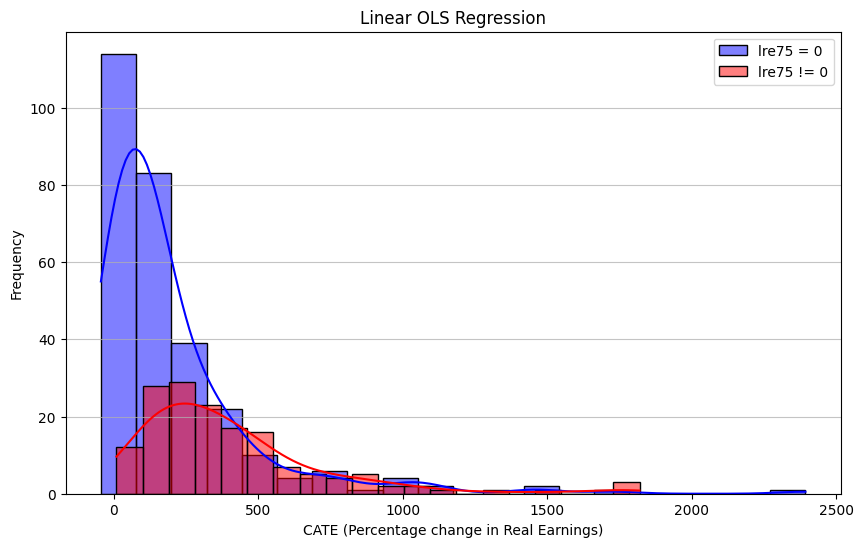

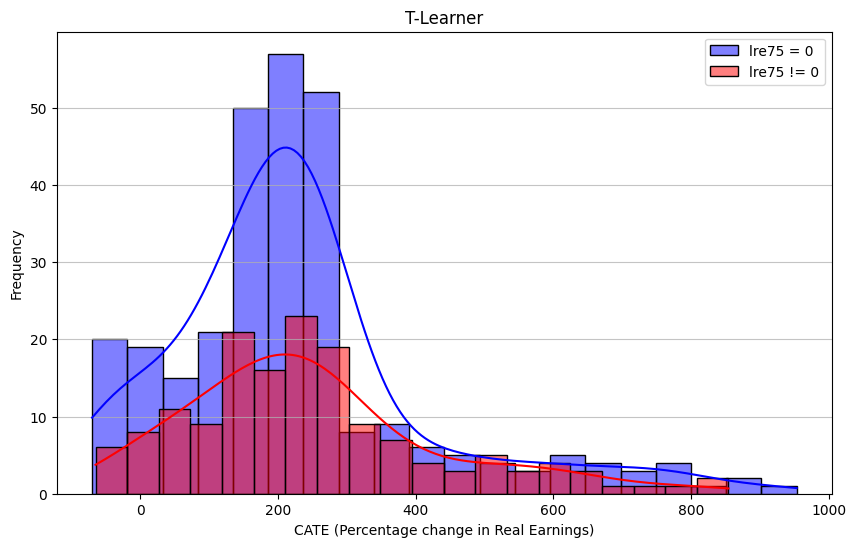

In [18]:
# Linear OLS
plot_df_lre75_comparison = pd.DataFrame({
    'CATE': cate_pc,
    'lre75': df['lre75'].values
})

# Split into 2 groups
plot_df_lre75_comparison['lre75_group'] = np.where(
    plot_df_lre75_comparison['lre75'] == 0, 'lre75 = 0', 'lre75 != 0'
)

mean_cate_by_lre75_group = plot_df_lre75_comparison.groupby('lre75_group')['CATE'].mean().reset_index()

plot_df_lre75_zero = plot_df_lre75_comparison[plot_df_lre75_comparison['lre75'] == 0].copy()
plot_df_lre75_non_zero = plot_df_lre75_comparison[plot_df_lre75_comparison['lre75'] != 0].copy()


plt.figure(figsize=(10, 6))

if not plot_df_lre75_zero.empty:
    sns.histplot(plot_df_lre75_zero['CATE'], kde=True, bins=20, color='blue', label='lre75 = 0')
    mean_cate_lre75_zero_dist = plot_df_lre75_zero['CATE'].mean()

if not plot_df_lre75_non_zero.empty:
    sns.histplot(plot_df_lre75_non_zero['CATE'], kde=True, bins=20, color='red', label='lre75 != 0')
    mean_cate_lre75_non_zero_dist = plot_df_lre75_non_zero['CATE'].mean()

plt.title('Linear OLS Regression')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.savefig('ols_lre75_distribution.png')
plt.show()


# T-learner
plot_df_lre75_comparison_t = pd.DataFrame({
    'CATE': cate_t_learner_pc_opt,
    'lre75': df['lre75'].values
})

plot_df_lre75_comparison_t['lre75_group'] = np.where(
    plot_df_lre75_comparison_t['lre75'] == 0, 'lre75 = 0', 'lre75 != 0'
)

mean_cate_by_lre75_group_t = plot_df_lre75_comparison_t.groupby('lre75_group')['CATE'].mean().reset_index()

plot_df_lre75_zero_t = plot_df_lre75_comparison_t[plot_df_lre75_comparison_t['lre75'] == 0].copy()
plot_df_lre75_non_zero_t = plot_df_lre75_comparison_t[plot_df_lre75_comparison_t['lre75'] != 0].copy()

plt.figure(figsize=(10, 6))

if not plot_df_lre75_zero_t.empty:
    sns.histplot(plot_df_lre75_zero_t['CATE'], kde=True, bins=20, color='blue', label='lre75 = 0')
    mean_cate_lre75_zero_dist = plot_df_lre75_zero_t['CATE'].mean()

if not plot_df_lre75_non_zero_t.empty:
    sns.histplot(plot_df_lre75_non_zero_t['CATE'], kde=True, bins=20, color='red', label='lre75 != 0')
    mean_cate_lre75_non_zero_dist = plot_df_lre75_non_zero_t['CATE'].mean()

plt.title('T-Learner')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.savefig('t_learner_lre75_distribution.png')
plt.show()

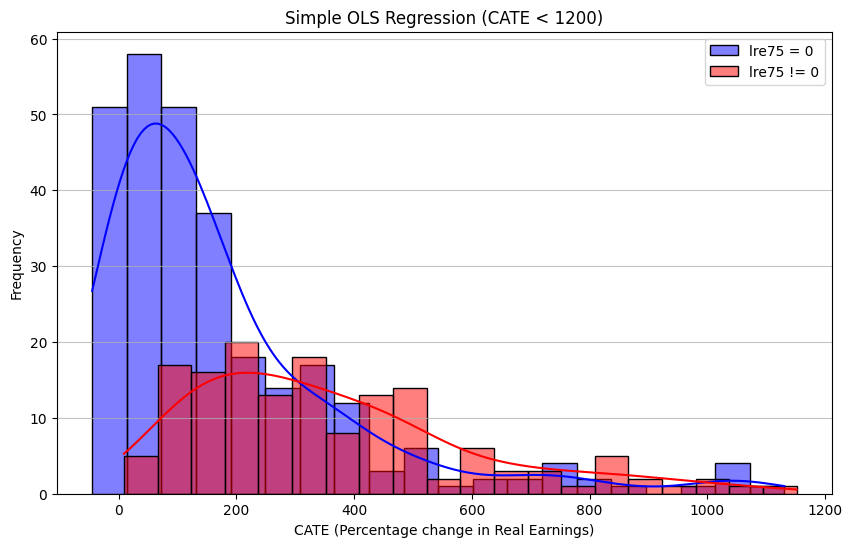

In [19]:
# Plot using filtered OLS-CATE

plot_df_lre75_comparison = pd.DataFrame({
    'CATE': cate_pc,
    'lre75': df['lre75'].values
})

plot_df_lre75_comparison = plot_df_lre75_comparison[plot_df_lre75_comparison['CATE'] < 1200].copy()

plot_df_lre75_comparison['lre75_group'] = np.where(
    plot_df_lre75_comparison['lre75'] == 0, 'lre75 = 0', 'lre75 != 0'
)

mean_cate_by_lre75_group = plot_df_lre75_comparison.groupby('lre75_group')['CATE'].mean().reset_index()

plot_df_lre75_zero = plot_df_lre75_comparison[plot_df_lre75_comparison['lre75'] == 0].copy()
plot_df_lre75_non_zero = plot_df_lre75_comparison[plot_df_lre75_comparison['lre75'] != 0].copy()

plt.figure(figsize=(10, 6))

if not plot_df_lre75_zero.empty:
    sns.histplot(plot_df_lre75_zero['CATE'], kde=True, bins=20, color='blue', label='lre75 = 0')
    mean_cate_lre75_zero_dist = plot_df_lre75_zero['CATE'].mean()

if not plot_df_lre75_non_zero.empty:
    sns.histplot(plot_df_lre75_non_zero['CATE'], kde=True, bins=20, color='red', label='lre75 != 0')
    mean_cate_lre75_non_zero_dist = plot_df_lre75_non_zero['CATE'].mean()

plt.title('Simple OLS Regression (CATE < 1200)')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.savefig('ols_lre75_distribution_1200.png')
plt.show()

## By Race

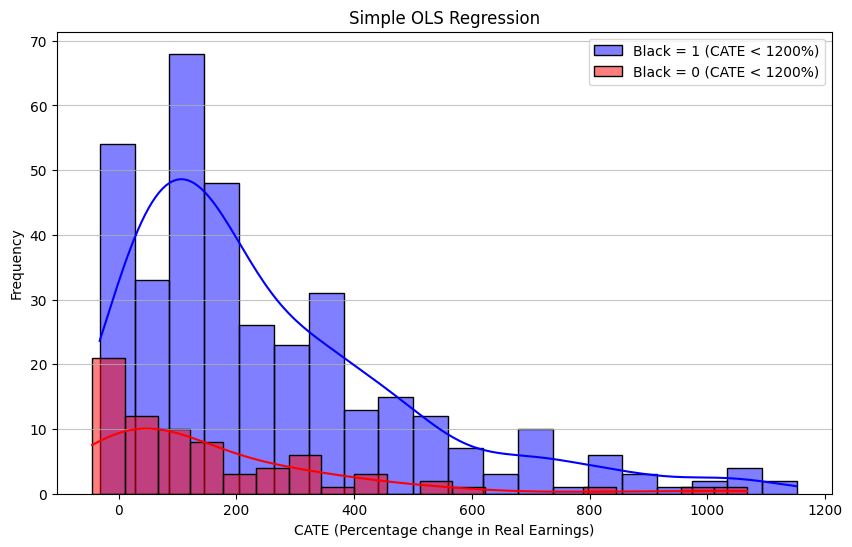

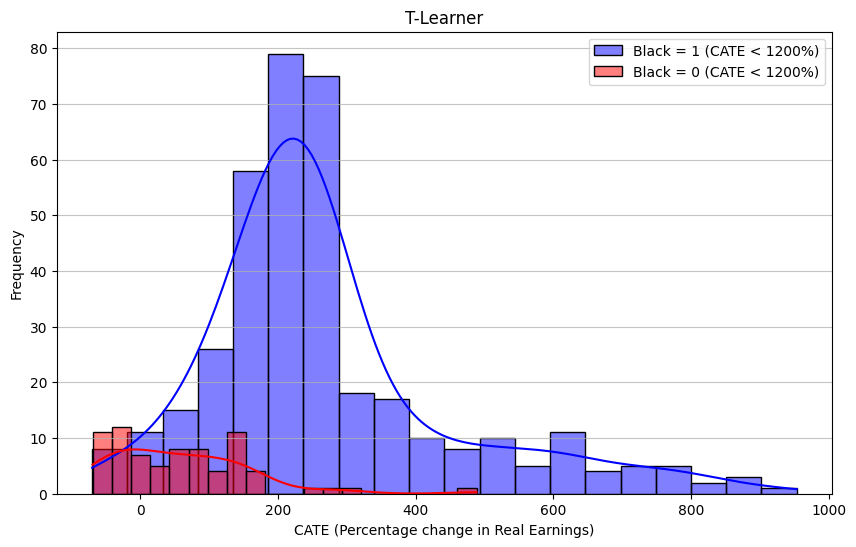

In [20]:
# Linear OLS
plot_df = pd.DataFrame({'CATE': cate_pc, 'Black': df['black'].values})

plot_df_black_1 = plot_df[plot_df['Black'] == 1]
plot_df_black_0 = plot_df[plot_df['Black'] == 0]

# Filter CATE values
plot_df_black_1_filtered = plot_df_black_1[plot_df_black_1['CATE'] < 1200].copy()
plot_df_black_0_filtered = plot_df_black_0[plot_df_black_0['CATE'] < 1200].copy()

plt.figure(figsize=(10, 6))

if not plot_df_black_1_filtered.empty:
    sns.histplot(plot_df_black_1_filtered['CATE'], kde=True, bins=20, color='blue', label='Black = 1 (CATE < 1200%)')

if not plot_df_black_0_filtered.empty:
    sns.histplot(plot_df_black_0_filtered['CATE'], kde=True, bins=20, color='red', label='Black = 0 (CATE < 1200%)')

plt.title('Simple OLS Regression')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.savefig('ols_black_distribution_1200.png')
plt.show()



# T-Learner
plot_df_t = pd.DataFrame({'CATE': cate_t_learner_pc_opt, 'Black': df['black'].values})

plot_df_black_1_t = plot_df_t[plot_df_t['Black'] == 1]
plot_df_black_0_t = plot_df_t[plot_df_t['Black'] == 0]

plot_df_black_1_filtered_t = plot_df_black_1_t[plot_df_black_1_t['CATE'] < 1200].copy()
plot_df_black_0_filtered_t = plot_df_black_0_t[plot_df_black_0_t['CATE'] < 1200].copy()

plt.figure(figsize=(10, 6))

if not plot_df_black_1_filtered_t.empty:
    sns.histplot(plot_df_black_1_filtered_t['CATE'], kde=True, bins=20, color='blue', label='Black = 1 (CATE < 1200%)')

if not plot_df_black_0_filtered_t.empty:
    sns.histplot(plot_df_black_0_filtered_t['CATE'], kde=True, bins=20, color='red', label='Black = 0 (CATE < 1200%)')


plt.title('T-Learner')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.savefig('tl_black_distribution_filtered.png')
plt.show()

## By Years of education

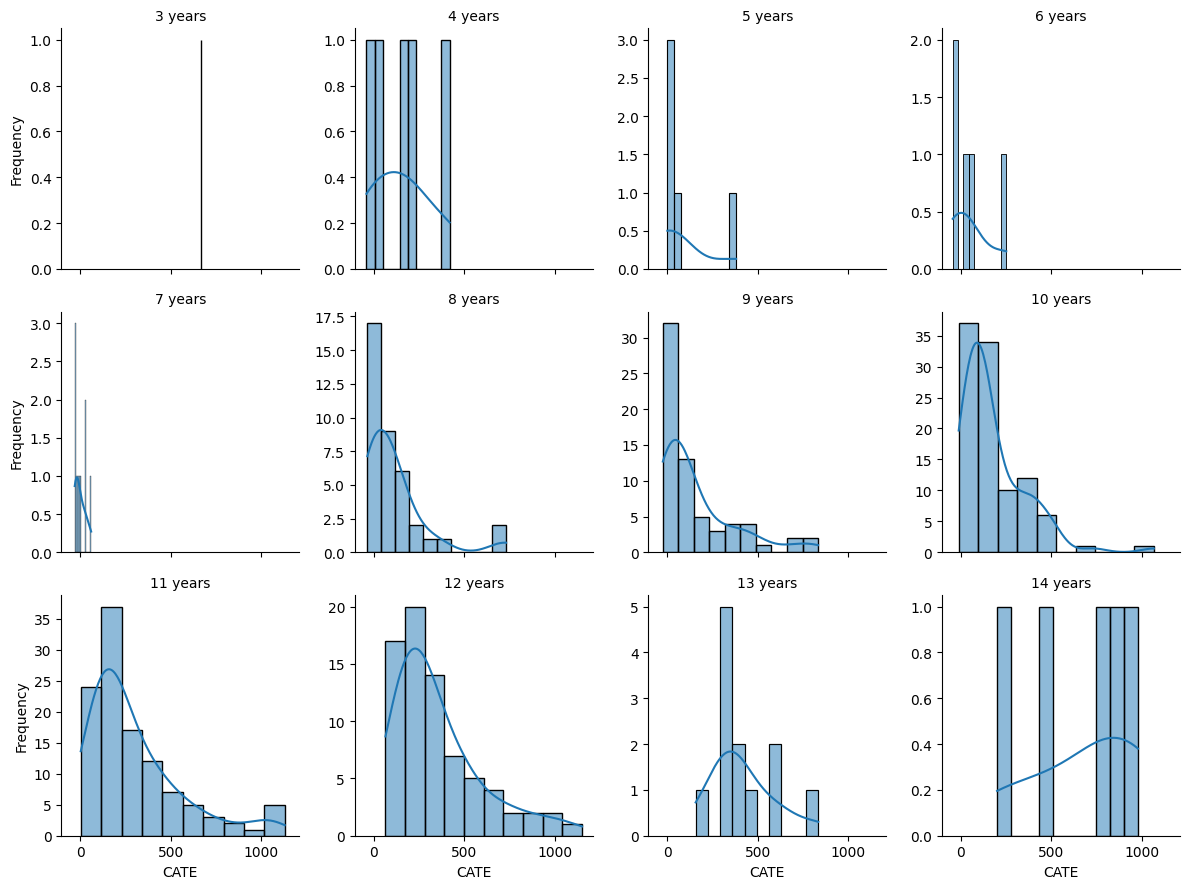

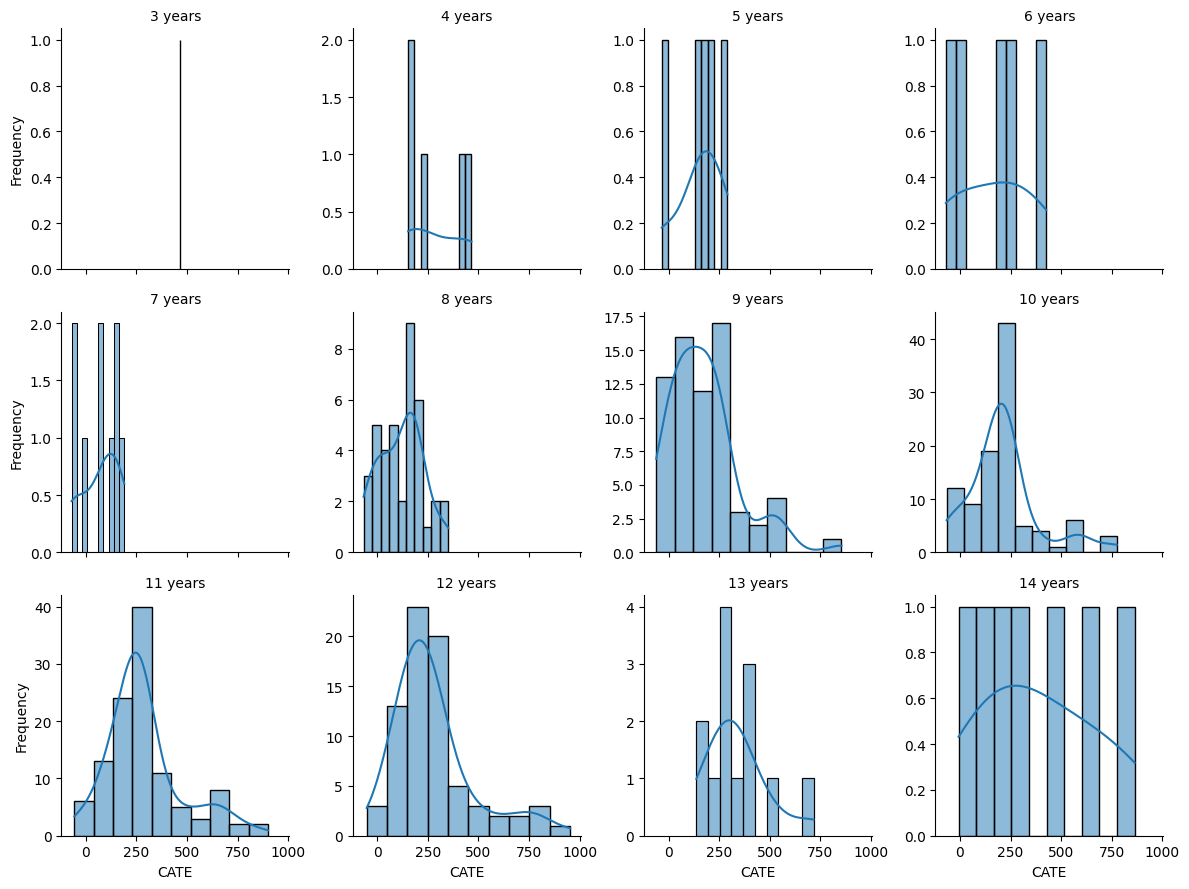

In [21]:
# Linear OLS
plot_df_educ = pd.DataFrame({'CATE': cate_pc, 'Education': df['educ'].values})

plot_df_educ_sorted = plot_df_educ.sort_values(by='Education')

# Filter CATE values
plot_df_educ_filtered = plot_df_educ_sorted[
    (plot_df_educ_sorted['CATE'] < 1200) &
    (~plot_df_educ_sorted['Education'].isin([15, 16]))
].copy()

graph_filtered = sns.FacetGrid(plot_df_educ_filtered, col='Education', col_wrap=4, height=3, sharex=True, sharey=False)
graph_filtered.map(sns.histplot, 'CATE', kde=True, bins=10)
graph_filtered.set_axis_labels('CATE', 'Frequency')
graph_filtered.set_titles('{col_name} years')
#plt.suptitle('Simple OLS Regression (CATE < 1200%)', y=1.02)
plt.tight_layout()
plt.savefig('ols_educ_distribution_1200.png')
plt.show()



# T-learner
plot_df_educ_t = pd.DataFrame({'CATE': cate_t_learner_pc_opt, 'Education': df['educ'].values})

plot_df_educ_sorted_t = plot_df_educ_t.sort_values(by='Education')

# Determine unique education levels
unique_educ_levels = np.sort(plot_df_educ_sorted_t['Education'].unique())
col_wrap = 4
num_unique_levels = len(unique_educ_levels)

# Preparations to remove the last row (empty plots as too few participants have very high years of education)
if num_unique_levels > 0:
    remainder = num_unique_levels % col_wrap
    if remainder == 0:
        levels_to_remove = col_wrap
    else:
        levels_to_remove = remainder
else:
    levels_to_remove = 0

if levels_to_remove > 0:
    excluded_levels = unique_educ_levels[-levels_to_remove:]
    # Filter out the excluded levels
    plot_df_educ_filtered_t = plot_df_educ_sorted_t[~plot_df_educ_sorted_t['Education'].isin(excluded_levels)]
else:
    plot_df_educ_filtered_t = plot_df_educ_sorted_t.copy()


graph = sns.FacetGrid(plot_df_educ_filtered_t, col='Education', col_wrap=col_wrap, height=3, sharex=True, sharey=False)
graph.map(sns.histplot, 'CATE', kde=True, bins=10)
graph.set_axis_labels('CATE', 'Frequency')
graph.set_titles('{col_name} years')
#plt.suptitle('T-Learner', y=1.02)
plt.tight_layout()
plt.savefig('tl_educ_distribution.png')
plt.show()

## By Age

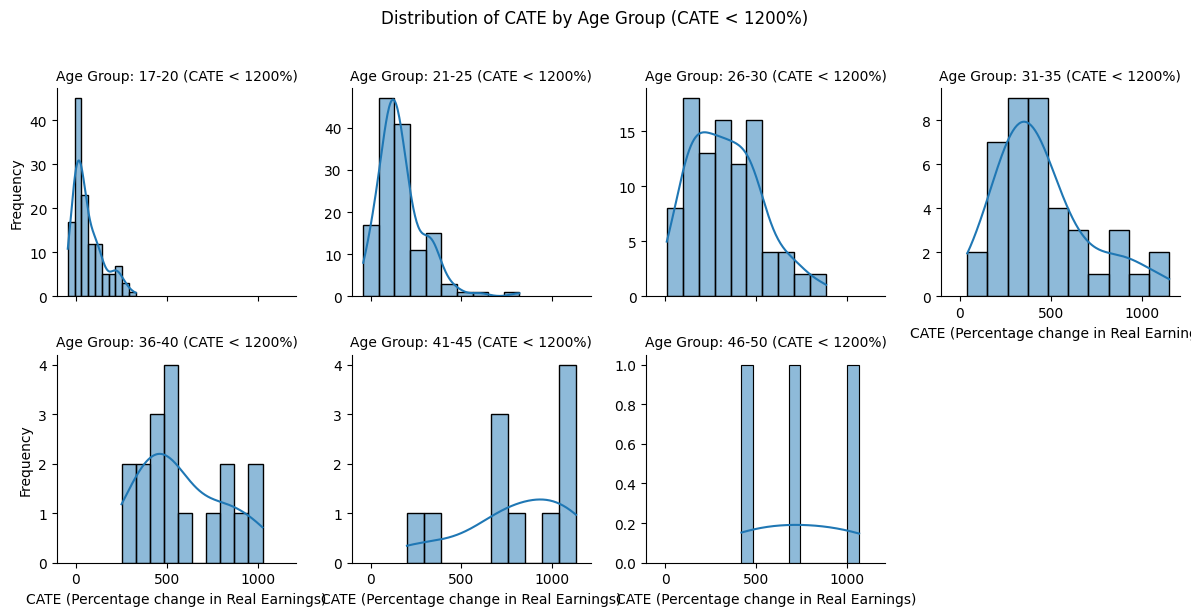

In [22]:
plot_df_age = pd.DataFrame({
    'CATE': cate_pc,
    'Age': df['age'].values
})

plot_df_age_sorted = plot_df_age.sort_values(by='Age')

# Filter CATE values
plot_df_age_filtered = plot_df_age_sorted[
    plot_df_age_sorted['CATE'] < 1200
].copy()

# Define age bins and labels for grouping
age_bins = [16, 20, 25, 30, 35, 40, 45, 50]
age_labels = ['17-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50'] # ages 51-55 & 56+ were removed because they are empty

plot_df_age_filtered['Age_Group'] = pd.cut(
    plot_df_age_filtered['Age'],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

graph_filtered_age = sns.FacetGrid(plot_df_age_filtered, col='Age_Group', col_wrap=4, height=3, sharex=True, sharey=False)
graph_filtered_age.map(sns.histplot, 'CATE', kde=True, bins=10)
graph_filtered_age.set_axis_labels('CATE (Percentage change in Real Earnings)', 'Frequency')
graph_filtered_age.set_titles('Age Group: {col_name} (CATE < 1200%)')
plt.suptitle('Distribution of CATE by Age Group (CATE < 1200%)', y=1.02)
plt.tight_layout()
plt.show()

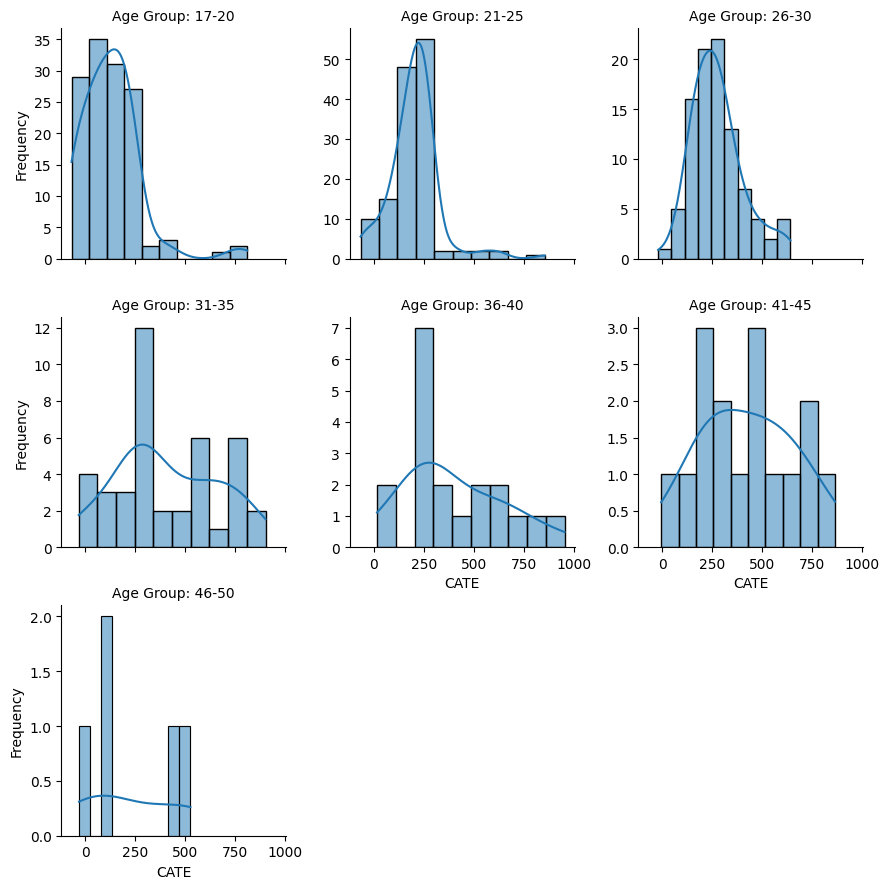

In [23]:
plot_df_age = pd.DataFrame({
    'CATE': cate_t_learner_pc_opt,
    'Age': df['age'].values
})

plot_df_age_sorted = plot_df_age.sort_values(by='Age')

# Filter CATE values
plot_df_age_filtered = plot_df_age_sorted[
    plot_df_age_sorted['CATE'] < 1200
].copy()

# Define age bins and labels for grouping
age_bins = [16, 20, 25, 30, 35, 40, 45, 50]
age_labels = ['17-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50'] # 51-55 & 56+ were dropped because they were empty

plot_df_age_filtered['Age_Group'] = pd.cut(
    plot_df_age_filtered['Age'],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

graph_filtered_age = sns.FacetGrid(plot_df_age_filtered, col='Age_Group', col_wrap=3, height=3, sharex=True, sharey=False)
graph_filtered_age.map(sns.histplot, 'CATE', kde=True, bins=10)
graph_filtered_age.set_axis_labels('CATE', 'Frequency')
graph_filtered_age.set_titles('Age Group: {col_name}')
#plt.suptitle('Distribution of CATE by Age Group (CATE < 1200%)', y=1.02)
plt.tight_layout()
plt.savefig('tl_age_distribution_1200.png')
plt.show()

# Conclusion

(no code needed)